In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import DataFrame 
import nltk
import random

from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn import neighbors
from scipy.spatial.distance import cosine
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

import re
import string
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.externals import joblib
import Recommenders as Recommenders
import Evaluation as Evaluation

In [21]:
import warnings 
warnings.filterwarnings('ignore')

In [26]:
import math
import json
import time
import seaborn as sns

In [5]:
data = pd.read_csv('ratings_Electronics.csv')

In [8]:
data.columns=['useid','productid','ratings','timestamp']

In [9]:
data.head()

,useid,productid,ratings,timestamp
0,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
1,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
2,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
3,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200
4,A1QGNMC6O1VW39,0511189877,5.0,1397433600


In [10]:
print(data.columns)
print(data.shape)

Index(['useid', 'productid', 'ratings', 'timestamp'], dtype='object')
(7824481, 4)


In [13]:
data = data.drop('timestamp', axis = True)

In [14]:
data.head(10)

,useid,productid,ratings
0,A2CX7LUOHB2NDG,0321732944,5.0
1,A2NWSAGRHCP8N5,0439886341,1.0
2,A2WNBOD3WNDNKT,0439886341,3.0
3,A1GI0U4ZRJA8WN,0439886341,1.0
4,A1QGNMC6O1VW39,0511189877,5.0
5,A3J3BRHTDRFJ2G,0511189877,2.0
6,A2TY0BTJOTENPG,0511189877,5.0
7,A34ATBPOK6HCHY,0511189877,5.0
8,A89DO69P0XZ27,0511189877,5.0
9,AZYNQZ94U6VDB,0511189877,5.0


In [16]:
data.dtypes

useid         object
productid     object
ratings      float64
dtype: object

In [18]:
data.isnull().sum()

useid        0
productid    0
ratings      0
dtype: int64

In [19]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ratings,7824481.0,4.012337,1.38091,1.0,3.0,5.0,5.0,5.0


In [24]:
# min rating & max rating from:
print('The minimum rating is: %d' %(data['ratings'].min()))
print('The maximum rating is: %d' %(data['ratings'].max()))

The minimum rating is: 1
The maximum rating is: 5


C:\Users\sugan\Anaconda3\lib\site-packages\seaborn\categorical.py:3666: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


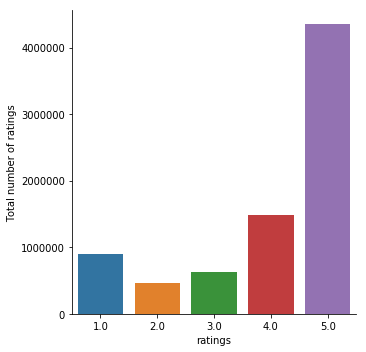

In [27]:
# ratings distribution
data1 = sns.factorplot("ratings", data=data, kind='count')
data1.set_ylabels("Total number of ratings") 

In [30]:
# check for unique data
print('Number of unique userid = ', data['useid'].nunique())
print('Number of unique productid = ', data['productid'].nunique())

Number of unique userid =  4201696
Number of unique productid =  476001


In [31]:
# show top 10 users w.r.t. rating
data_rated = data.groupby('useid').size().sort_values(ascending=False)[:10]
data_rated

useid
A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
A1ODOGXEYECQQ8    380
A36K2N527TXXJN    314
A2AY4YUOX2N1BQ    311
AWPODHOB4GFWL     308
A25C2M3QF9G7OQ    296
dtype: int64

In [34]:
# take useid with 50 or more number of ratings >> the data50 will store this data
counts = data['useid'].value_counts()
data50 = data[data['useid'].isin(counts[counts >= 50].index)]

In [36]:
print('No. of useid having rated 50 or more prductid =', len(data50))
print('No. of unique useid = ', data50['useid'].nunique())
print('No. of unique productid = ', data50['productid'].nunique())

No. of useid having rated 50 or more prductid = 125871
No. of unique useid =  1540
No. of unique productid =  48190


In [37]:
# Train and test data in the ratio 70:30
train_data, test_data = train_test_split(data50, test_size = 0.3, random_state=0)

print(train_data.head(5))

                  useid   productid  ratings
6595852  A2BYV7S1QP2YIG  B009EAHVTA      5.0
4738240   AB094YABX21WQ  B0056XCEAA      1.0
4175595  A3D0UM4ZD2CMAW  B004I763AW      5.0
3753015   AATWFX0ZZSE6C  B0040NPHMO      3.0
1734766  A1NNMOD9H36Q8E  B0015VW3BM      4.0


In [41]:
train_data.shape

(88109, 3)

In [42]:
test_data.shape

(37762, 3)

In [43]:
# Q4. Build Popularity Recommender model. 
# Count of useid for each unique productid as recommendation score 

train_data1 = train_data.groupby('productid').agg({'useid': 'count'}).reset_index()
train_data1.rename(columns = {'useid': 'score'},inplace=True)
train_data1.head()

,productid,score
0,0594451647,1
1,0594481813,1
2,0970407998,1
3,0972683275,3
4,1400501466,4


In [45]:
# Sorting productid on recommendation score 
train_data2 = train_data1.sort_values(['score', 'productid'], ascending = [0,1]) 
      
# Generate a recommendation rank based upon score 
train_data2['Rank'] = train_data2['score'].rank(ascending=0, method='first') 

#Get the top 5 recommendations 
data_recom = train_data2.head(5) 
data_recom

,productid,score,Rank
30847,B0088CJT4U,133,1.0
30287,B007WTAJTO,124,2.0
19647,B003ES5ZUU,122,3.0
8752,B000N99BBC,114,4.0
30555,B00829THK0,97,5.0


In [46]:
# Use popularity based recommender model to make predictions
def recommend(useid):     
    useid_recom = data_recom 
          
    #Add user_id column for which the recommendations are being generated 
    useid_recom['useid'] = useid 
      
    #Bring user_id column to the front 
    cols = useid_recom.columns.tolist() 
    cols = cols[-1:] + cols[:-1] 
    useid_recom = useid_recom[cols] 
          
    return useid_recom 

In [47]:
find_recom = [10,125,200]   # This list is user choice.
for i in find_recom:
    print("Here is the recommendation for the useid: %d\n" %(i))
    print(recommend(i))    
    print("\n") 

Here is the recommendation for the useid: 10

       useid   productid  score  Rank
30847     10  B0088CJT4U    133   1.0
30287     10  B007WTAJTO    124   2.0
19647     10  B003ES5ZUU    122   3.0
8752      10  B000N99BBC    114   4.0
30555     10  B00829THK0     97   5.0


Here is the recommendation for the useid: 125

       useid   productid  score  Rank
30847    125  B0088CJT4U    133   1.0
30287    125  B007WTAJTO    124   2.0
19647    125  B003ES5ZUU    122   3.0
8752     125  B000N99BBC    114   4.0
30555    125  B00829THK0     97   5.0


Here is the recommendation for the useid: 200

       useid   productid  score  Rank
30847    200  B0088CJT4U    133   1.0
30287    200  B007WTAJTO    124   2.0
19647    200  B003ES5ZUU    122   3.0
8752     200  B000N99BBC    114   4.0
30555    200  B00829THK0     97   5.0




In [48]:
# Note: Its a popularity-based recommender model, therefore recommendations remain the same for all users
# This predicts products based on the popularity

In [49]:
# Q5. Build Collaborative Filtering model.

In [50]:
data_cf = pd.concat([train_data, test_data]).reset_index()
data_cf.tail()

,index,useid,productid,ratings
125866,621871,A3OXHLG6DIBRW8,B0007UQNOA,3.0
125867,1942807,A365PBEOWM7EI7,B001DVZXC0,3.0
125868,5219962,A3QDY9I0CNMD2W,B005WXQO3W,5.0
125869,876607,AR18DH5SL9F73,B000EPR7AC,5.0
125870,975288,A3VL4RXCWNSR3H,B000GM7MRG,5.0


In [52]:
# useid-based Collaborative Filtering
# Matrix with row per 'useid' and column per 'productid' 
datamat = data_cf.pivot(index = 'useid', columns ='productid', values = 'ratings').fillna(0)
print(datamat.shape)
datamat.head()

(1540, 48190)


productid,0594451647,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
useid,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
datamat['user_index'] = np.arange(0, datamat.shape[0], 1)
datamat.head()

productid,0594451647,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,...,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8,user_index
useid,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


In [54]:
datamat.set_index(['user_index'], inplace=True)

# Actual ratings given by users
datamat.head()

productid,0594451647,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
user_index,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
# Model-based Collaborative Filtering: Singular Value Decomposition
from scipy.sparse.linalg import svds

In [57]:
U, sigma, Vt = svds(datamat, k = 50)
# Construct diagonal array in SVD
sigma = np.diag(sigma)

In [58]:
useid_predicted_ratings = np.dot(np.dot(U, sigma), Vt) 

# Predicted ratings
data_pred = pd.DataFrame(useid_predicted_ratings, columns = datamat.columns)
data_pred.head()

productid,0594451647,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
0,0.005086,0.002178,0.003668,-0.040843,0.009640,0.006808,0.020659,0.000649,0.020331,0.005633,...,0.000238,-0.061477,0.001214,-0.123433,0.028490,0.016109,0.002855,-0.174568,0.011367,-0.012997
1,0.002286,-0.010898,-0.000724,0.130259,0.007506,-0.003350,0.063711,-0.000674,0.016111,-0.002433,...,-0.000038,0.013766,0.001473,0.025588,-0.042103,0.004251,0.002177,-0.024362,-0.014765,0.038570
2,-0.001655,-0.002675,-0.007355,0.007264,0.005152,-0.003986,-0.003480,0.006961,-0.006606,-0.002719,...,-0.001708,-0.051040,0.000325,-0.054867,0.017870,-0.004996,-0.002426,0.083928,-0.112205,0.005964
3,0.001856,0.011019,-0.005910,-0.014134,0.000179,0.001877,-0.005391,-0.001709,0.004968,0.001402,...,0.000582,-0.009326,-0.000465,-0.048315,0.023302,0.006790,0.003380,0.005460,-0.015263,-0.025996
4,0.001115,-0.002670,0.011018,0.014434,0.010319,0.006002,0.017151,0.003726,0.001404,0.005645,...,0.000207,0.023761,0.000747,-0.019347,-0.012749,0.001026,0.001364,-0.020580,0.011828,0.012770


In [75]:
# Recommend the items with the highest predicted ratings

def recommend_items(useid, datamat, data_pred, num_recom):
      
    useid_index = useid-1 # index starts at 0
    
    # Get and sort the user's ratings
    sorted_user_ratings = datamat.iloc[useid_index].sort_values(ascending=False)
    #sorted_user_ratings
    sorted_user_predictions = data_pred.iloc[useid_index].sort_values(ascending=False)
    #sorted_user_predictions

    temp = pd.concat([sorted_user_ratings, sorted_user_predictions], axis=1)
    temp.index.name = 'Recommended Items'
    temp.columns = ['user_ratings', 'user_predictions']
    
    temp = temp.loc[temp.user_ratings == 0]   
    temp = temp.sort_values('user_predictions', ascending=False)
    print('\nBelow are the recommended items for user(useid = {}):\n'.format(useid))
    print(temp.head(num_recom))

In [77]:
#Enter 'useid' and 'num_recom' for the user #
useid = 130
num_recom = 10
recommend_items(useid, datamat, data_pred, num_recom)


Below are the recommended items for user(useid = 130):

                   user_ratings  user_predictions
Recommended Items                                
B001XURP7W                  0.0          0.416836
B001TH7GUU                  0.0          0.340493
B0019EHU8G                  0.0          0.320717
B000BQ7GW8                  0.0          0.309996
B000VX6XL6                  0.0          0.306760
B002WE6D44                  0.0          0.299465
B000JMJWV2                  0.0          0.297867
B003ES5ZUU                  0.0          0.288077
B005FYNSPK                  0.0          0.285475
B000S5Q9CA                  0.0          0.261243


Q6. Evaluate both the models. Once the model is trained on the training data, it can be used to compute the error (RMSE) on predictions made on the test data

In [80]:
final_ratings_matrix = data50.pivot(index = 'useid', columns ='productid', values = 'ratings').fillna(0)
print('Shape of final_ratings_matrix: ', final_ratings_matrix.shape)

given_num_of_ratings = np.count_nonzero(final_ratings_matrix)
print('given_num_of_ratings = ', given_num_of_ratings)
possible_num_of_ratings = final_ratings_matrix.shape[0] * final_ratings_matrix.shape[1]
print('possible_num_of_ratings = ', possible_num_of_ratings)
density = (given_num_of_ratings/possible_num_of_ratings)
density *= 100
print ('density: {:4.2f}%'.format(density))

Shape of final_ratings_matrix:  (1540, 48190)
given_num_of_ratings =  125871
possible_num_of_ratings =  74212600
density: 0.17%


In [81]:
# Actual ratings given by the users
final_ratings_matrix.head()

productid,0594451647,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
useid,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [82]:
# Average ACTUAL rating for each item
final_ratings_matrix.mean().head()

productid
0594451647    0.003247
0594481813    0.001948
0970407998    0.003247
0972683275    0.012338
1400501466    0.012987
dtype: float64

In [84]:
# Predicted ratings 
data_pred.head()

productid,0594451647,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
0,0.005086,0.002178,0.003668,-0.040843,0.009640,0.006808,0.020659,0.000649,0.020331,0.005633,...,0.000238,-0.061477,0.001214,-0.123433,0.028490,0.016109,0.002855,-0.174568,0.011367,-0.012997
1,0.002286,-0.010898,-0.000724,0.130259,0.007506,-0.003350,0.063711,-0.000674,0.016111,-0.002433,...,-0.000038,0.013766,0.001473,0.025588,-0.042103,0.004251,0.002177,-0.024362,-0.014765,0.038570
2,-0.001655,-0.002675,-0.007355,0.007264,0.005152,-0.003986,-0.003480,0.006961,-0.006606,-0.002719,...,-0.001708,-0.051040,0.000325,-0.054867,0.017870,-0.004996,-0.002426,0.083928,-0.112205,0.005964
3,0.001856,0.011019,-0.005910,-0.014134,0.000179,0.001877,-0.005391,-0.001709,0.004968,0.001402,...,0.000582,-0.009326,-0.000465,-0.048315,0.023302,0.006790,0.003380,0.005460,-0.015263,-0.025996
4,0.001115,-0.002670,0.011018,0.014434,0.010319,0.006002,0.017151,0.003726,0.001404,0.005645,...,0.000207,0.023761,0.000747,-0.019347,-0.012749,0.001026,0.001364,-0.020580,0.011828,0.012770


In [85]:
# Average PREDICTED rating for each item
data_pred.mean().head()

productid
0594451647    0.001953
0594481813    0.002875
0970407998    0.003355
0972683275    0.010343
1400501466    0.004871
dtype: float64

In [86]:
data_rmse = pd.concat([final_ratings_matrix.mean(), data_pred.mean()], axis=1)
data_rmse.columns = ['Avg_actual_ratings', 'Avg_predicted_ratings']
print(data_rmse.shape)
data_rmse['item_index'] = np.arange(0, data_rmse.shape[0], 1)
data_rmse.head()

(48190, 2)


,Avg_actual_ratings,Avg_predicted_ratings,item_index
productid,,,
0594451647,0.003247,0.001953,0
0594481813,0.001948,0.002875,1
0970407998,0.003247,0.003355,2
0972683275,0.012338,0.010343,3
1400501466,0.012987,0.004871,4


In [87]:
RMSE = round((((data_rmse.Avg_actual_ratings - data_rmse.Avg_predicted_ratings) ** 2).mean() ** 0.5), 5)
print('\nRMSE SVD Model = {} \n'.format(RMSE))


RMSE SVD Model = 0.00275 



In [88]:
# Q7. Get top - K ( K = 5) recommendations. 
# Since our goal is to recommend new products to each user based on his/her habits, we will recommend 5 new products.

In [89]:
## Enter 'useid' and 'num_recom' for the user #
useid = 200
num_recom = 5
recommend_items(useid, datamat, data_pred, num_recom)


Below are the recommended items for user(useid = 200):

                   user_ratings  user_predictions
Recommended Items                                
B008X9Z8NE                  0.0          1.141688
B0079UAT0A                  0.0          1.101302
B008X9Z528                  0.0          1.072300
B004CLYEFK                  0.0          1.025798
B008X9Z7N0                  0.0          1.002051


Q8. Summarise your insights.

Model-based Collaborative Filtering is a personalised recommender system
The Popularity-based recommender system is non-personalised and the recommendations are based on frequecy counts
The Popularity based model has recommended the same set of 5 products to all users
The Collaborative Filtering based model has recommended different list for esch user based on the user's past purchase history